In [1]:
import xarray as xr

In [2]:
import glob

files = sorted(glob.glob('AV/data/AV*.nc'))
print(len(files), files[:5], files[-5:])

# Peek at first two
for f in files[:3]:
    with xr.open_dataset(f) as ds:
        print(f, ds['time'].load().values[:3], ds['time'].load().values[-3:])

432 ['AV/data/AVY1980M10_.nc', 'AV/data/AVY1980M11_.nc', 'AV/data/AVY1980M12_.nc', 'AV/data/AVY1981M10_.nc', 'AV/data/AVY1981M11_.nc'] ['AV/data/AV_Y2015M5_.nc', 'AV/data/AV_Y2015M6_.nc', 'AV/data/AV_Y2015M7_.nc', 'AV/data/AV_Y2015M8_.nc', 'AV/data/AV_Y2015M9_.nc']
AV/data/AVY1980M10_.nc ['1980-09-30T21:59:59.121093747' '1980-09-30T23:00:00.878906252'
 '1980-10-01T00:00:00.000000000'] ['1980-10-31T23:00:00.878906252' '1980-11-01T00:00:00.000000000'
 '1980-11-01T00:59:59.121093747']
AV/data/AVY1980M11_.nc ['1980-10-31T21:59:59.121093747' '1980-10-31T23:00:00.878906252'
 '1980-11-01T00:00:00.000000000'] ['1980-11-30T23:00:00.878906252' '1980-12-01T00:00:00.000000000'
 '1980-12-01T00:59:59.121093747']
AV/data/AVY1980M12_.nc ['1980-11-30T21:59:59.121093747' '1980-11-30T23:00:00.878906252'
 '1980-12-01T00:00:00.000000000'] ['1980-12-31T23:00:00.878906252' '1981-01-01T00:00:00.000000000'
 '1981-01-01T00:59:59.121093747']


In [3]:
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',  # name of the time coordinate/dimension to concat
    parallel=True,
    chunks=
        'auto'# Half the spatial dimension
).sortby('time')
ds = ds.compute()
ds

<xarray.Dataset> Size: 345MB
Dimensions:  (time: 317304, lat: 135)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2016...
  * lat      (lat) float64 1kB -16.03 -15.95 -15.87 ... -5.242 -5.159 -5.076
Data variables:
    AV       (time, lat) float64 343MB 0.5831 0.6764 0.8434 ... 1.936 2.275 2.79

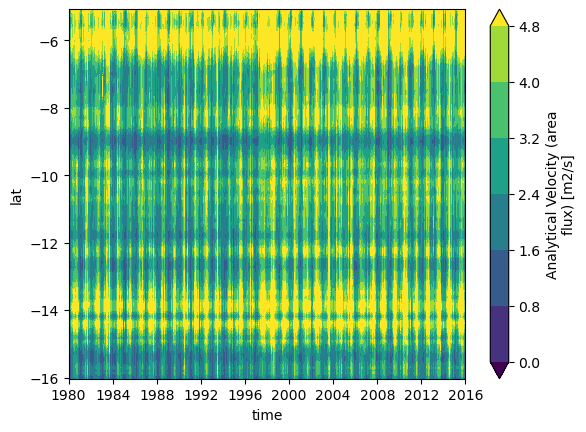

In [4]:
ds.AV.plot.contourf(robust=True,x='time')

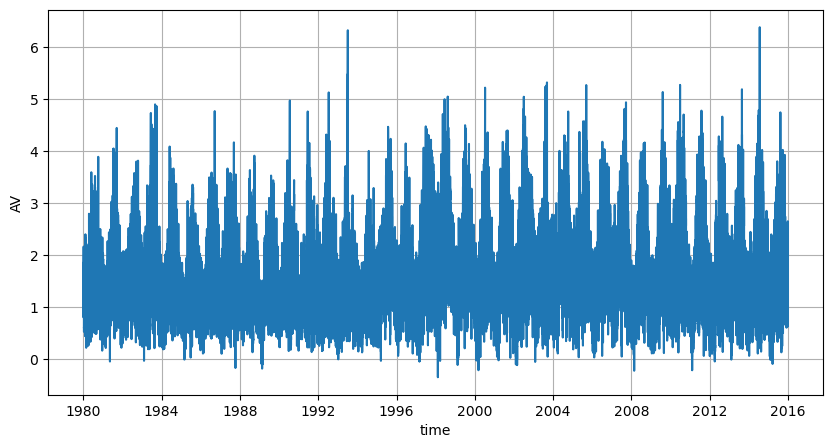

In [5]:
import matplotlib.pyplot as plt

ds.AV.mean(dim='lat').plot(figsize=(10,5))
plt.grid()

Text(0.5, 1.0, 'Seasonality')

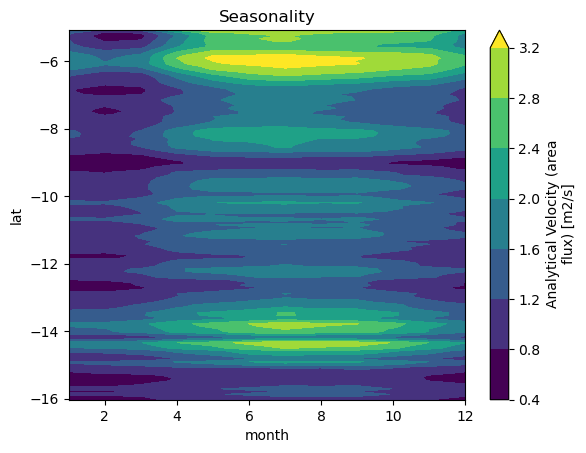

In [6]:
ds.AV.groupby('time.month').mean().plot.contourf(x='month', robust=True)
plt.title('Seasonality')

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


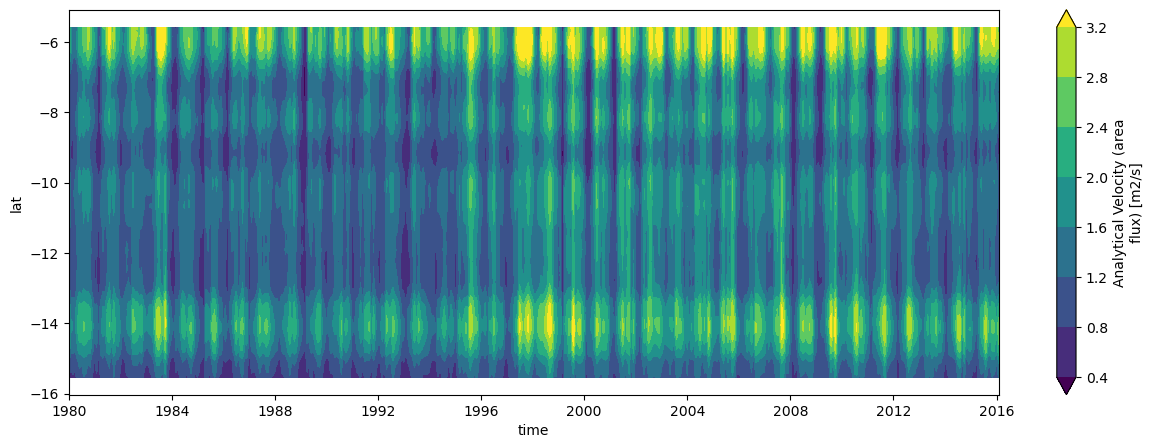

In [7]:
ds.AV.resample(time='1M').mean().rolling(lat=13, center=True).mean().plot.contourf(x='time',robust=True,figsize=(15,5))

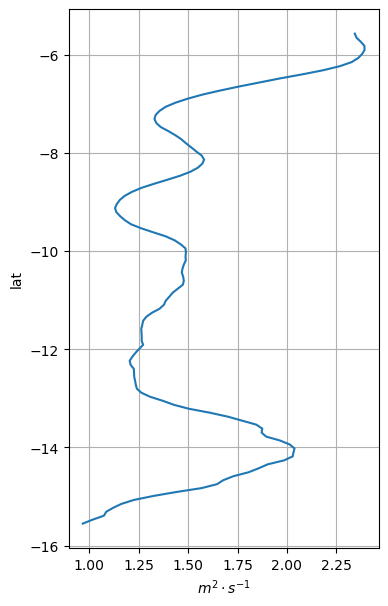

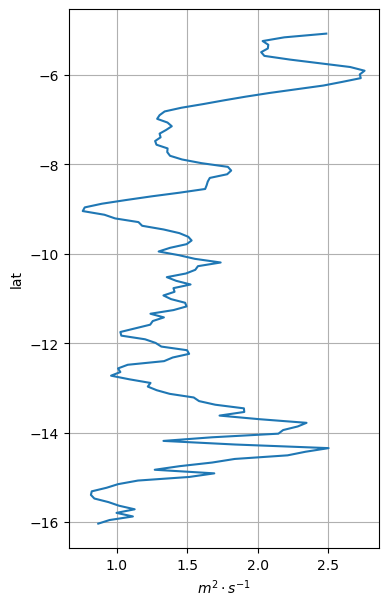

In [8]:
ds.AV.mean(dim='time').rolling(
    lat=13, center=True).mean().rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

ds.AV.mean(dim='time').rename('$m^{2} \cdot s^{-1}$').plot(y='lat',figsize=(4,7))
plt.grid()

In [9]:
# ds.AV.to_netcdf('AV/AV_H.nc')
# ds.AV.resample(time='1M').mean().to_netcdf('AV/AV_M.nc')

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


### $W_{mld}$ CROCO

In [27]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path

In [28]:
## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [29]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [30]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK100km.kml"
R1 = kml2struct(arch_kml_zona1)

MLD_30km = "../../../NHCS/Processed/MLD30km.kml"
mld_R = kml2struct(MLD_30km)
# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [31]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds_ = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds_.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

/tmp/ipykernel_440071/70548169.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [32]:

WMLD_data = loadmat("../../../NHCS/Processed/WMLD_MLD.mat")
WMLD_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)*expanded_mask*inshore_mask),
    },
    coords = {
        'lon':ds_.lon_rho.compute().values[0,:],
        'lat':ds_.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


Text(0.5, 1.0, 'AV vs Wmld')

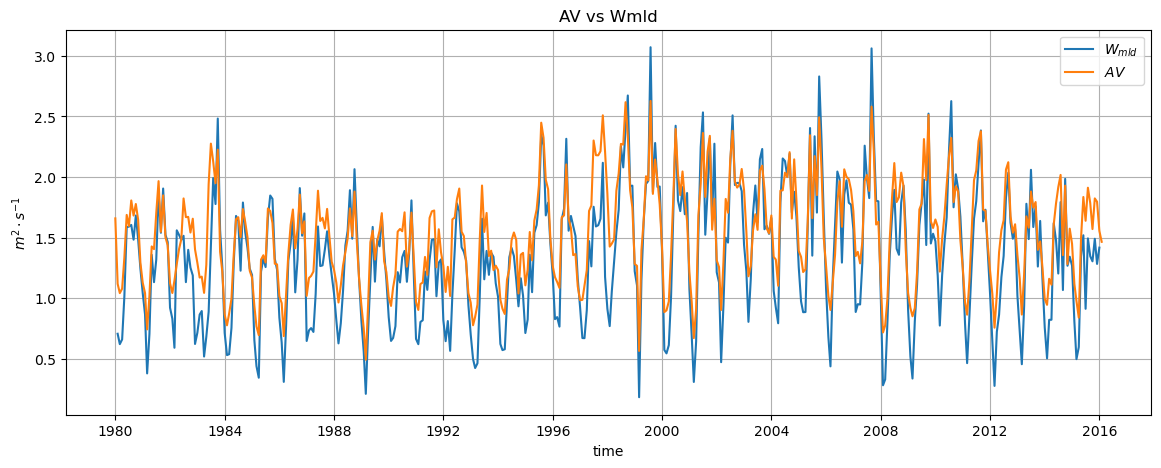

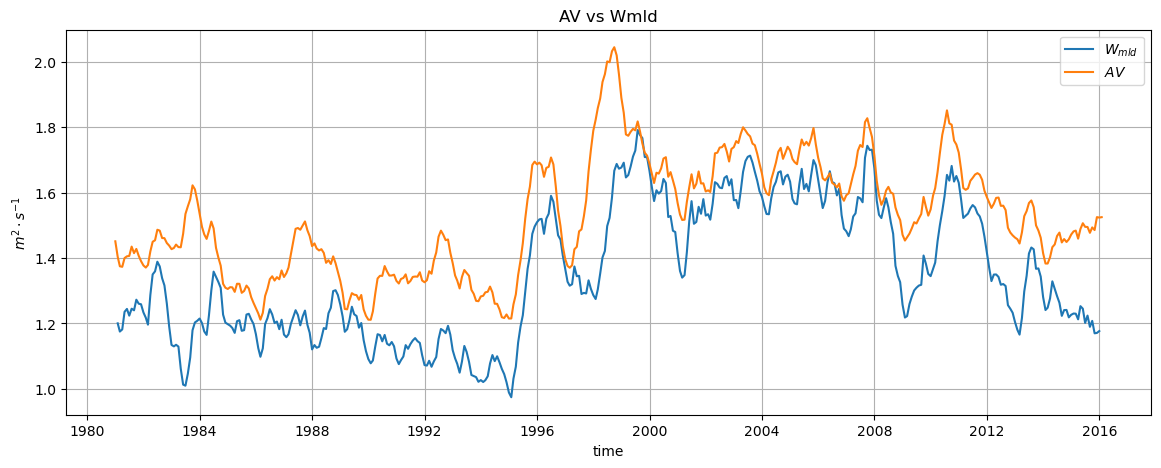

In [55]:
(WMLD_ds.WMLD.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'))*111e3).rename('$m^2 \cdot s^{-1}$').plot(figsize=(14,5),label='$W_{mld}$')
ds.AV.resample(time='1M').mean().mean('lat').rename('$m^2 \cdot s^{-1}$').plot(label='$AV$')
plt.grid()
plt.legend()
plt.title('AV vs Wmld')

(WMLD_ds.WMLD.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'))*111e3).rolling(time=13).mean().plot(figsize=(14,5),label='$W_{mld}$')
ds.AV.resample(time='1M').mean().mean('lat').rolling(time=13).mean().rename('$m^2 \cdot s^{-1}$').plot(label='$AV$')
plt.grid()
plt.legend()
plt.title('AV vs Wmld')